# Temporal Plots

In [1]:
import json

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Config

In [2]:
# Dataset configuration
dataset = "aitv2"
scenario = "santos"

In [3]:
# Hyperparameters
model = "multiclass"
features = "aug"
subset = "full"
window_size = "w100"

## Load data

In [4]:
data_dir = f"../data/processed/{dataset}/{scenario}/{features}/windowed/{window_size}"
metrics_dir = f"../experiments/{dataset}/{scenario}/baselines/{model}/metrics"

exp_name = f"{model}_{features}_{window_size}_{subset}"
metrics_file = f"{metrics_dir}/{exp_name}.json"

In [5]:
# test_set = np.load(f"{data_dir}/y_test.npy", allow_pickle=True)
# test_set_length = len(test_set)
# print(f"Test set length: {test_set_length}")

In [6]:
df = pd.read_csv(
    f"../data/interim/{dataset}/{scenario}/flows_labeled/all_flows_labeled.csv"
)
df = df.sort_values("start_time").reset_index(drop=True)

In [7]:
df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")

phase_bounds = (
    df
    .groupby("phase", sort=True)["start_time_dt"]
    .agg(["min", "max"])
)

phase_starts = phase_bounds['min'].to_dict()

phase_bounds

,min,max
phase,,
0,2022-01-14 00:00:02.425734043,2022-01-17 23:59:53.819441080
1,2022-01-14 00:00:09.731323957,2022-01-16 07:16:04.975357056
2,2022-01-17 11:15:12.900707960,2022-01-17 11:22:44.917221069
3,2022-01-17 11:22:57.162303925,2022-01-17 11:24:14.067639112
4,2022-01-17 11:24:16.209572077,2022-01-17 11:57:27.041970015


## Create DF with Misclassified Samples

In [8]:
with open(metrics_file) as f:
    metrics = json.load(f)

real_flow_indices = metrics["real_flow_indices"]
misclassified = df.iloc[real_flow_indices].copy()
misclassified["y_true"] = metrics["y_true"]
misclassified["y_pred"] = metrics["y_pred"]

In [9]:
metrics

{'Accuracy': 0.9991847440805331,
 'Macro Precision': 0.9110414608588264,
 'Macro Recall': 0.9554965547692367,
 'Macro F1': 0.9304803447211807,
 'False Alarms': 101,
 'False Alarm Rate': 0.0007562710595282665,
 'Missed Attacks': 14,
 'Detection Rate': 0.9981358189081225,
 'Confusion Matrix (actual_pred)': [[133449, 7, 81, 4, 9],
  [0, 5141, 0, 0, 0],
  [2, 0, 2266, 0, 0],
  [1, 0, 0, 9, 0],
  [11, 0, 0, 0, 80]],
 'misclassified_indices': [2279,
  2290,
  2291,
  66755,
  70430,
  100432,
  101516,
  109862,
  115335,
  115336,
  115881,
  115883,
  115885,
  115924,
  115925,
  116023,
  116062,
  116063,
  116064,
  116065,
  116066,
  116067,
  116100,
  116101,
  116102,
  116103,
  116250,
  116357,
  116603,
  116757,
  117008,
  117385,
  117868,
  118365,
  119458,
  119589,
  119767,
  120105,
  120777,
  120778,
  121669,
  121686,
  121689,
  121693,
  121727,
  121731,
  124275,
  124278,
  124280,
  124287,
  124289,
  124301,
  124312,
  124317,
  124330,
  124342,
  124344

In [10]:
def is_causal_violation(row, phase_starts):
    pred_phase = row['y_pred']
    t = row['start_time_dt']

    if pred_phase == 0 or pred_phase == 1:
        return False
    
    prev_phase = pred_phase - 1
    
    if prev_phase in phase_starts:
        if t < phase_starts[prev_phase]:
            return True

    return False


def is_regression_violation(row, phase_starts):
    pred_phase = row['y_pred']
    t = row['start_time_dt']

    if pred_phase == 0:
        return False

    next_phase = pred_phase + 1

    if next_phase in phase_starts:
        if t >= phase_starts[next_phase]:
            return True

    return False


def temp_metrics(misclassified, f1, phase_starts):

    df = misclassified.copy()

    df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")
    df["end_time_dt"]   = pd.to_datetime(df["end_time_dt"],   errors="coerce")
    
    df['causal_violation'] = df.apply(
        is_causal_violation,
        axis=1,
        phase_starts=phase_starts
    )

    df['regression_violation'] = df.apply(
        is_regression_violation,
        axis=1,
        phase_starts=phase_starts
    )
    
    wrong = df[df['phase'] != df['y_pred']]
    causal = wrong[wrong['causal_violation']]
    regression = wrong[(~wrong['causal_violation']) & (wrong['regression_violation'])]
    plausible = wrong[(~wrong['causal_violation']) & (~wrong['regression_violation'])]
    
    total_wrong = len(wrong)
    causal_rate = len(causal) / total_wrong if total_wrong > 0 else 0
    regression_rate = len(regression) / total_wrong if total_wrong > 0 else 0
    plausible_rate = len(plausible) / total_wrong if total_wrong > 0 else 0

    temp_score = f1 - 0.5 * causal_rate - 0.2 * regression_rate
    
    temp_metrics_dict = {
        "total_wrong": total_wrong,
        "num_causal": len(causal),
        "num_regression": len(regression),
        "num_plausible": len(plausible),
        "causal_rate": causal_rate,
        "regression_rate": regression_rate,
        "plausible_rate": plausible_rate,
        "temp_score": temp_score
    }

    return wrong, causal, regression, plausible, temp_metrics_dict

In [11]:
f1 = metrics["Macro F1"]
wrong, causal, regression, plausible, temp_metrics_dict = temp_metrics(misclassified, f1, phase_starts)

print(f"Total misclassifications: {temp_metrics_dict['total_wrong']}")
print(f"Causal violations: {temp_metrics_dict['num_causal']} ({temp_metrics_dict['causal_rate']:.2%})")
print(f"Regression violations: {temp_metrics_dict['num_regression']} ({temp_metrics_dict['regression_rate']:.2%})")
print(f"Temporal‑plausible errors: {temp_metrics_dict['num_plausible']} ({temp_metrics_dict['plausible_rate']:.2%})")

Total misclassifications: 115
Causal violations: 0 (0.00%)
Regression violations: 0 (0.00%)
Temporal‑plausible errors: 115 (100.00%)


In [12]:
def plot_temp_consistency(
    df, 
    phase_bounds, 
    causal,
    regression,
    plausible,
    temp_metrics_dict,
    exp_name, 
    out_dir,
    attack_start=None, 
    attack_end=None,
    save_plot=True, 
    show_plot=True,
):
    
    df = df.copy()

    # Trim to specified attack window, if provided
    if attack_start is not None and attack_end is not None:
        df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")
        df["end_time_dt"]   = pd.to_datetime(df["end_time_dt"],   errors="coerce")
        df = df[(df["start_time_dt"] >= attack_start) & (df["end_time_dt"] <= attack_end)]
        
        causal      = causal[(causal["start_time_dt"] >= attack_start) & (causal["end_time_dt"] <= attack_end)]
        regression  = regression[(regression["start_time_dt"] >= attack_start) & (regression["end_time_dt"] <= attack_end)]
        plausible   = plausible[(plausible["start_time_dt"] >= attack_start) & (plausible["end_time_dt"] <= attack_end)]

    fig, ax = plt.subplots(figsize=(14, 5))

    edges  = phase_bounds["min"].tolist() + [phase_bounds["max"].iloc[-1]]
    values = phase_bounds.index.tolist()

    ax.stairs(
        values=values,
        edges=edges,
        linewidth=1,
        color="black",
        label="True phase"
    )

    values.append(5)
    ax.fill_between(
        edges,                    
        values,              
        [min(values) - 0.5]*len(values),  
        step="post",
        color="lightgray",
        alpha=0.2
    )

    ax.scatter(causal["start_time_dt"], causal["y_pred"], s=70, marker="X",
               color="red", alpha=0.9, label="Causal violations")

    ax.scatter(regression["start_time_dt"], regression["y_pred"], s=70, marker="X",
               color="orange", alpha=0.9, label="Regression violations")

    # ax.scatter(plausible["start_time_dt"], plausible["y_pred"], s=70, marker="X",
    #            color="blue", alpha=0.9, label="Temporal‑plausible errors")

    ax.set_ylim(-0.5, max(values) + 2)
    ax.set_xlim(df["start_time_dt"].min(), df["start_time_dt"].max())
    ax.set_xlabel("Time")
    ax.set_ylabel("Phase")
    ax.set_title(f"Temporal Consistency - Misclassifications")
    ax.set_yticks(sorted(df["phase"].unique()))
    ax.grid(alpha=0.2)

    textstr = (
        f"Causal: {temp_metrics_dict['num_causal']} "
        f"({temp_metrics_dict['causal_rate']:.1%})\n"
        f"Regression: {temp_metrics_dict['num_regression']} "
        f"({temp_metrics_dict['regression_rate']:.1%})\n"
        f"Plausible: {temp_metrics_dict['num_plausible']} "
        f"({temp_metrics_dict['plausible_rate']:.1%})"
    )

    ax.text(
        0.02, 0.95, textstr,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
    )
    
    ax.legend(
        frameon=True,
        facecolor="white",
        framealpha=0.9,
        loc="upper right"
    )

    fig.tight_layout()

    if save_plot:
        out_path = out_dir / f"{exp_name}.png"
        print(f"Saving plot to {out_path}...")
        fig.savefig(out_path, dpi=300, bbox_inches="tight")

    if show_plot:
        plt.show()


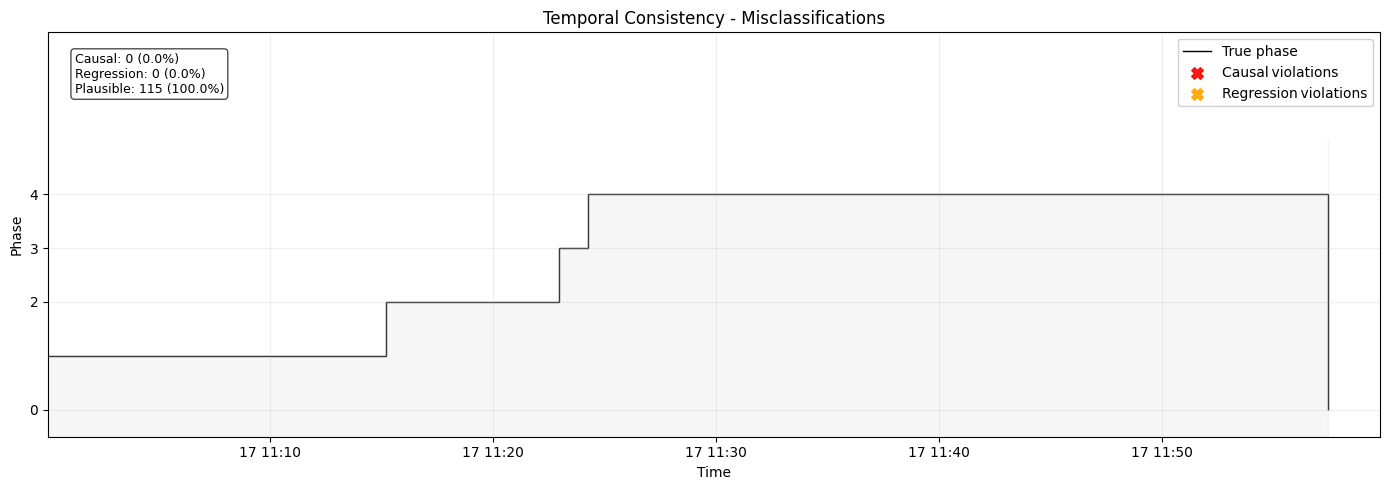

In [13]:
# santos
# attack_start = pd.Timestamp("2022-01-17 11:15")
# attack_end   = pd.Timestamp("2022-01-17 11:59")

attack_start = pd.Timestamp("2022-01-17 11:00")
attack_end   = pd.Timestamp("2022-01-17 12:00")

plot_temp_consistency(
    df, 
    phase_bounds, 
    causal,
    regression,
    plausible,
    temp_metrics_dict,
    exp_name=exp_name, 
    out_dir = "",
    attack_start=attack_start,
    attack_end=attack_end,
    save_plot=False
)


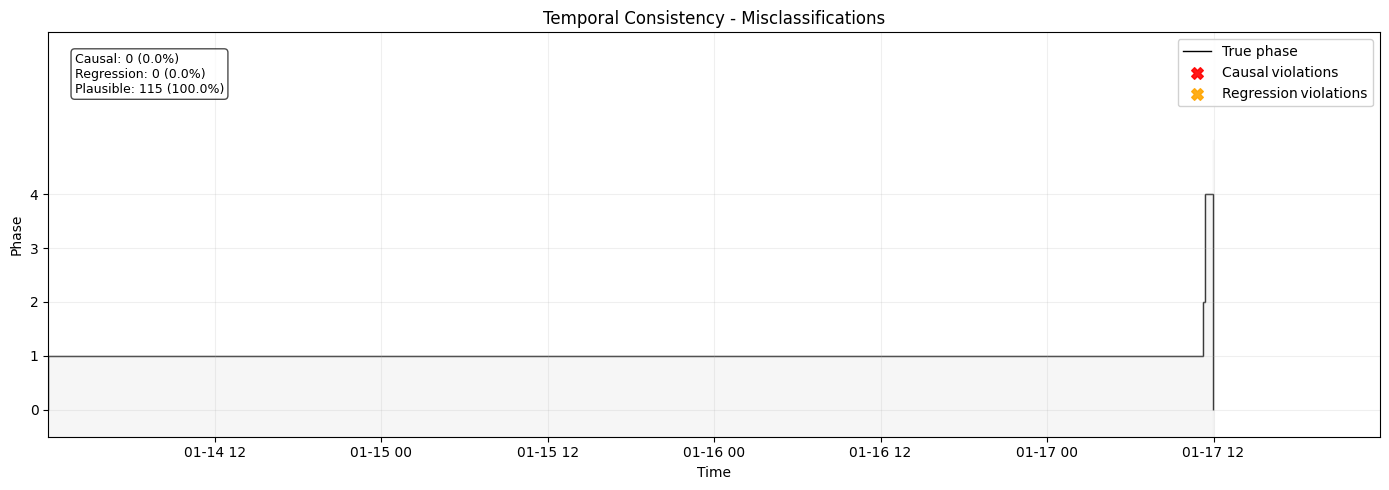

In [14]:
plot_temp_consistency(
    df, phase_bounds, 
    causal,
    regression,
    plausible,
    temp_metrics_dict,
    exp_name=exp_name, 
    out_dir = "",
    attack_start=None,
    attack_end=None,
    save_plot=False
)
